In [4]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [5]:
fmax=16
sfreq=fmax*2
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014008()
subject, session, run = 1, "session_0", "run_0"


In [6]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.781 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


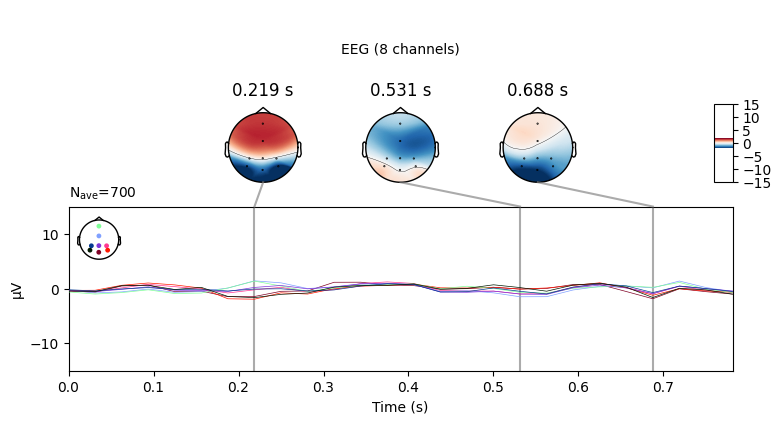

No projector specified for this dataset. Please consider the method self.add_proj.


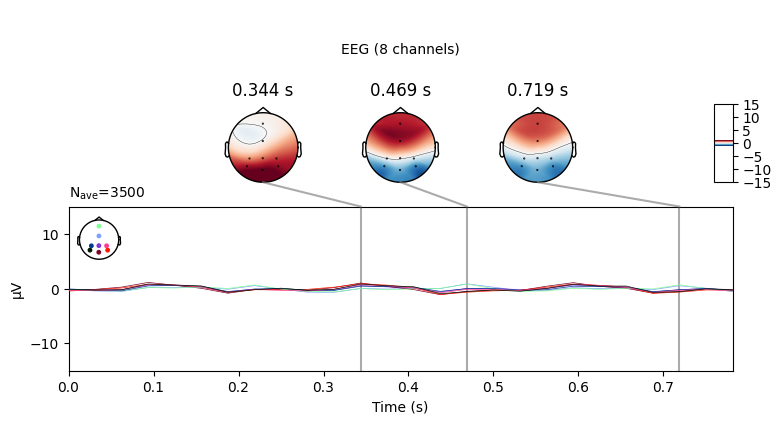

No projector specified for this dataset. Please consider the method self.add_proj.


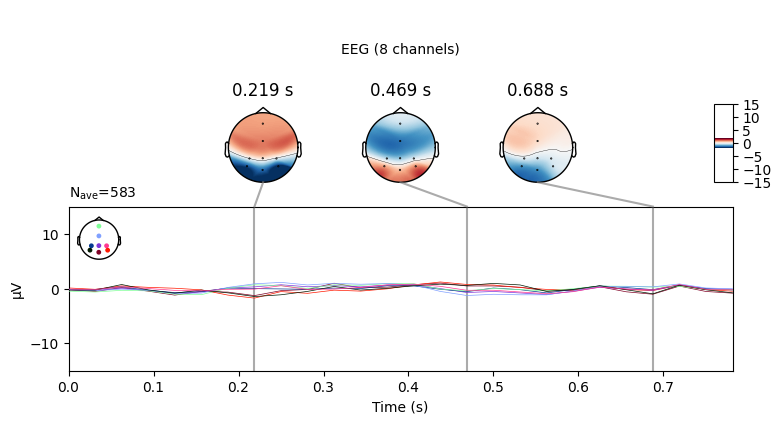

In [7]:
from mne import combine_evoked
target = epochs['Target'].average()
_ = target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
non_target = epochs['NonTarget'].average()
_ = non_target.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint(ts_args=dict(ylim=dict(eeg=[-15,15])))

In [8]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [9]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [10]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('numpy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]
"""
print(X_train.shape)
X_train, factors = tensorly.decomposition.partial_tucker(X_train, modes=(1,), rank=8)
factors = [factors[0],tl.eye(X_train.shape[2])]
print(X_train.shape)
X_test = tensorly.tenalg.multi_mode_dot(X_test, factors, modes=(1,), transpose=True)


#plt.semilogy(np.mean(np.abs(X_train), axis=(0,2)), label='space')
#plt.semilogy(np.mean(np.abs(X_train), axis=(0,1)), label='time')
#plt.legend()
"""
factors = [tl.eye(X_train.shape[1]),tl.eye(X_train.shape[2])]


In [11]:
import cupy

#fig, axs = plt.subplots(1, X_train.shape[1], figsize=(16,6))
#for i in range(X_train.shape[1]):
#    w = cupy.asnumpy(factors[0][:,i])
#    plot_topomap(w, epochs.info, axes=axs[i], show=False)


In [26]:
import scipy.linalg

thresh = .95
rank = [0]*2
X = tl.tensor(epochs.get_data(picks='eeg'))
for k in range(2):
    Xk = tl.unfold(X, mode=k+1)
    w,_ = scipy.linalg.eigh(Xk@Xk.T)
    w = w[::-1]
    variance = np.cumsum(w)/np.sum(w)
    rank[k] = np.nonzero(variance > thresh)[0][0]
print(rank)

[2, 21]


In [27]:
hoda = HODA(max_iter=256, rank=rank, tol=1e-12,
            initialize ='ones', verbose=True,
            shrinkage='oas', toeplitz=(1,), solver='diff-svd')
#%lprun -f  hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

[0/256]  shrinkage=0.0013  shrinkage=0.0483  step=4.7180e+00
[1/256]  shrinkage=0.0013  shrinkage=0.0336  step=1.5081e+00
[2/256]  shrinkage=0.0013  shrinkage=0.0338  step=6.7366e-02
[3/256]  shrinkage=0.0013  shrinkage=0.0338  step=3.0523e-02
[4/256]  shrinkage=0.0013  shrinkage=0.0338  step=1.3770e-03
[5/256]  shrinkage=0.0013  shrinkage=0.0338  step=3.8278e-04
[6/256]  shrinkage=0.0013  shrinkage=0.0338  step=2.5213e-05
[7/256]  shrinkage=0.0013  shrinkage=0.0338  step=6.5903e-06
[8/256]  shrinkage=0.0013  shrinkage=0.0338  step=1.9378e-06
[9/256]  shrinkage=0.0013  shrinkage=0.0338  step=5.3871e-07
[10/256]  shrinkage=0.0013  shrinkage=0.0338  step=3.0283e-08
[11/256]  shrinkage=0.0013  shrinkage=0.0338  step=1.2923e-08
[12/256]  shrinkage=0.0013  shrinkage=0.0338  step=2.5498e-09
[13/256]  shrinkage=0.0013  shrinkage=0.0338  step=7.3451e-10
[14/256]  shrinkage=0.0013  shrinkage=0.0338  step=3.7072e-11
[15/256]  shrinkage=0.0013  shrinkage=0.0338  step=1.9834e-11


HODA(max_iter=256, rank=[2, 21], solver='diff-svd', toeplitz=(1,), tol=1e-12,
     verbose=True)

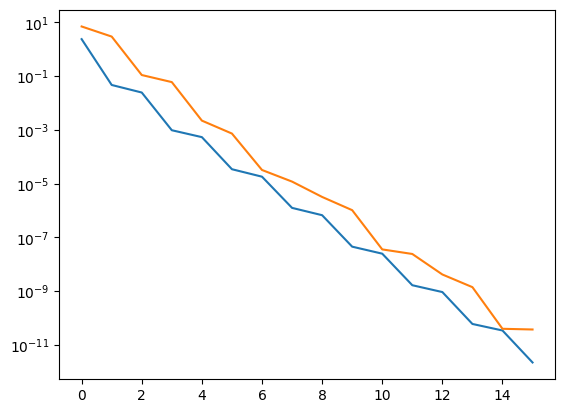

In [28]:
plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

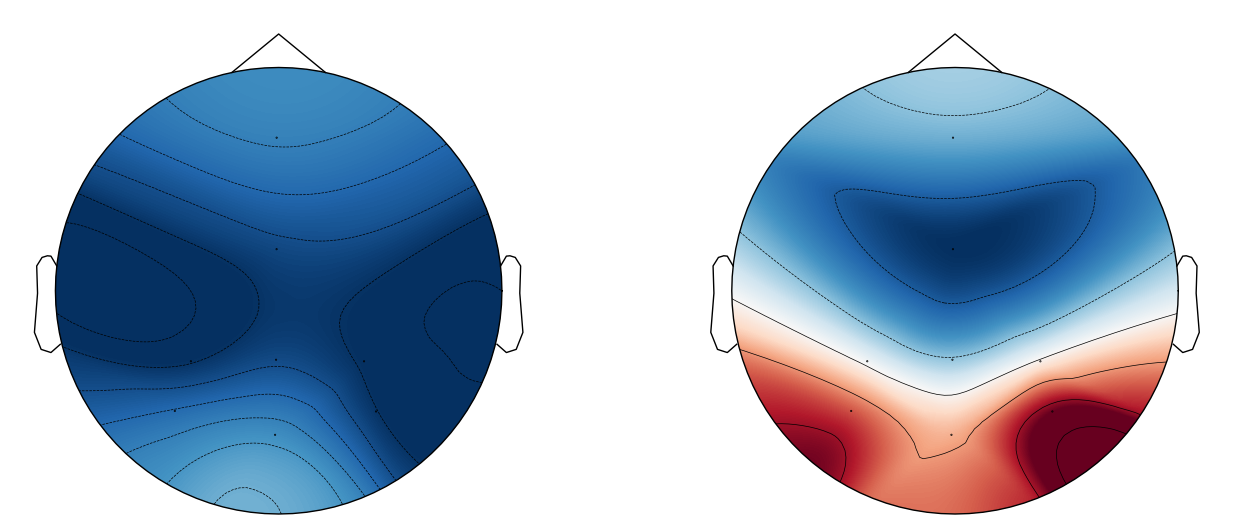

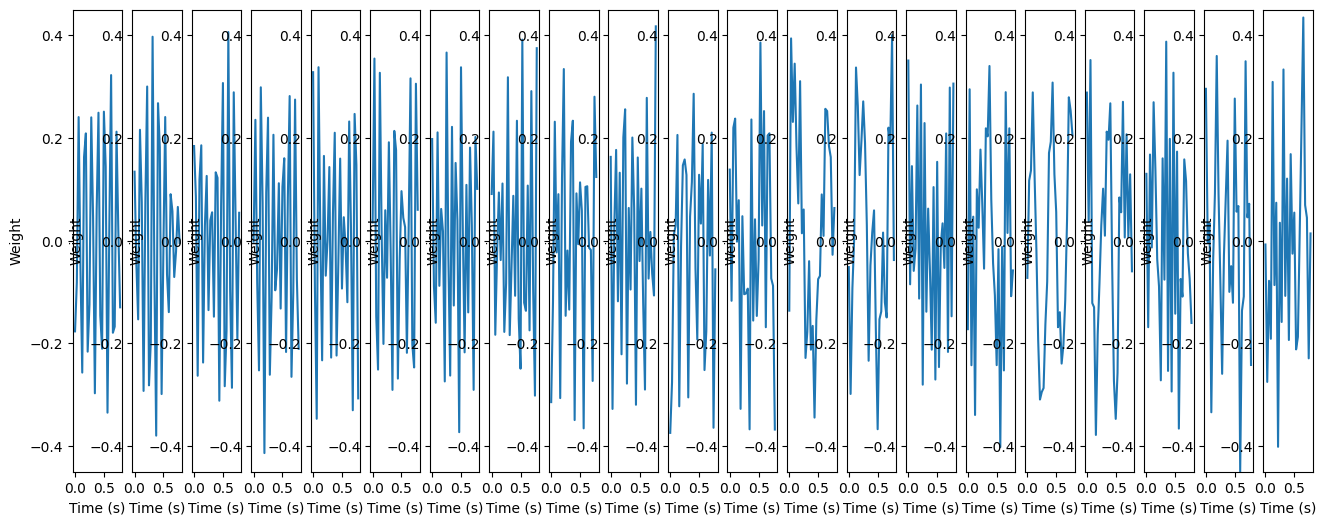

In [29]:
projs = [factors[k] @ p for k, p in enumerate(hoda.projs_)]

fig, axs = plt.subplots(1,hoda.rank[0], figsize=(16,6))
for i in range(hoda.rank[0]):
    w = cupy.asnumpy(projs[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(projs[1]))
fig, axs = plt.subplots(1,hoda.rank[1], figsize=(16,6))
for i in range(hoda.rank[1]):
    w = cupy.asnumpy(projs[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])


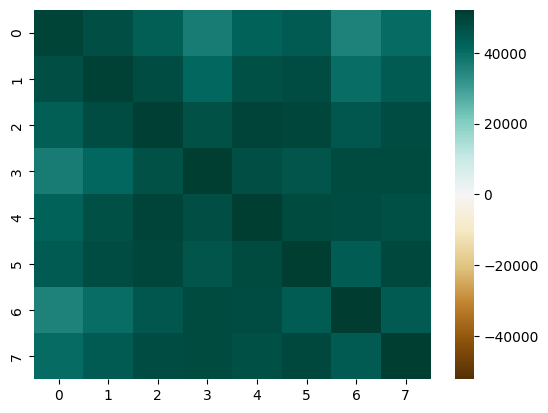

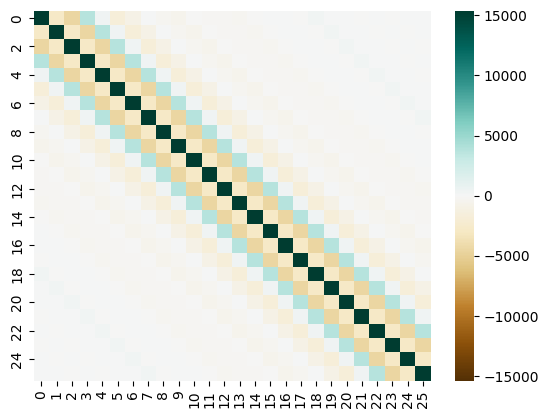

In [30]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

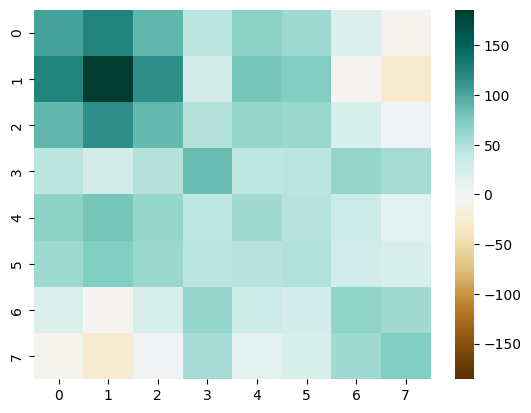

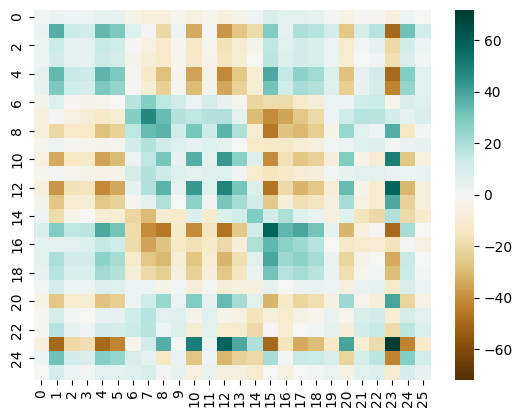

In [31]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

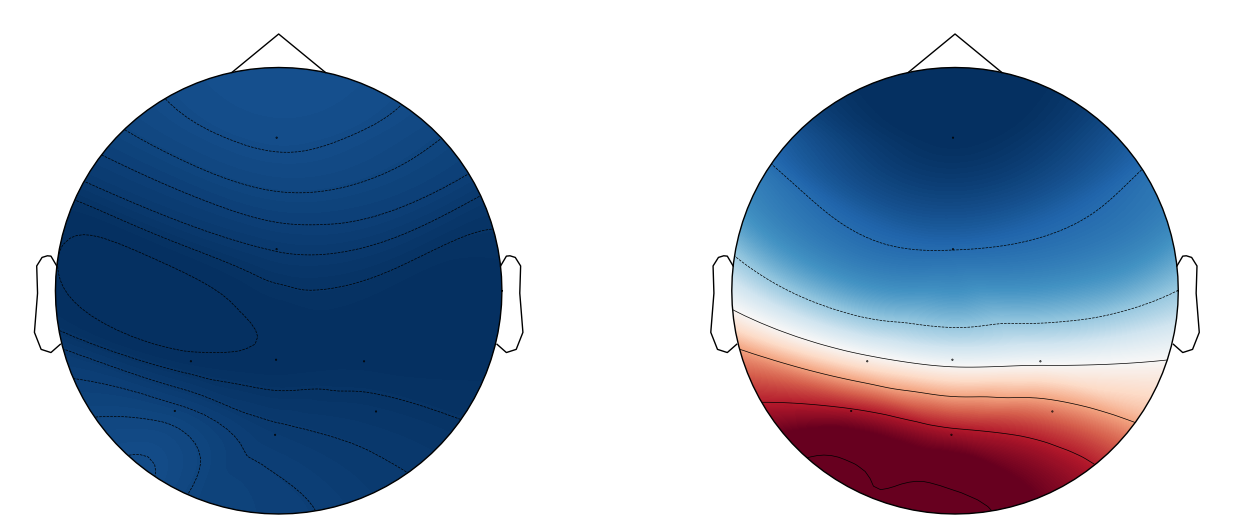

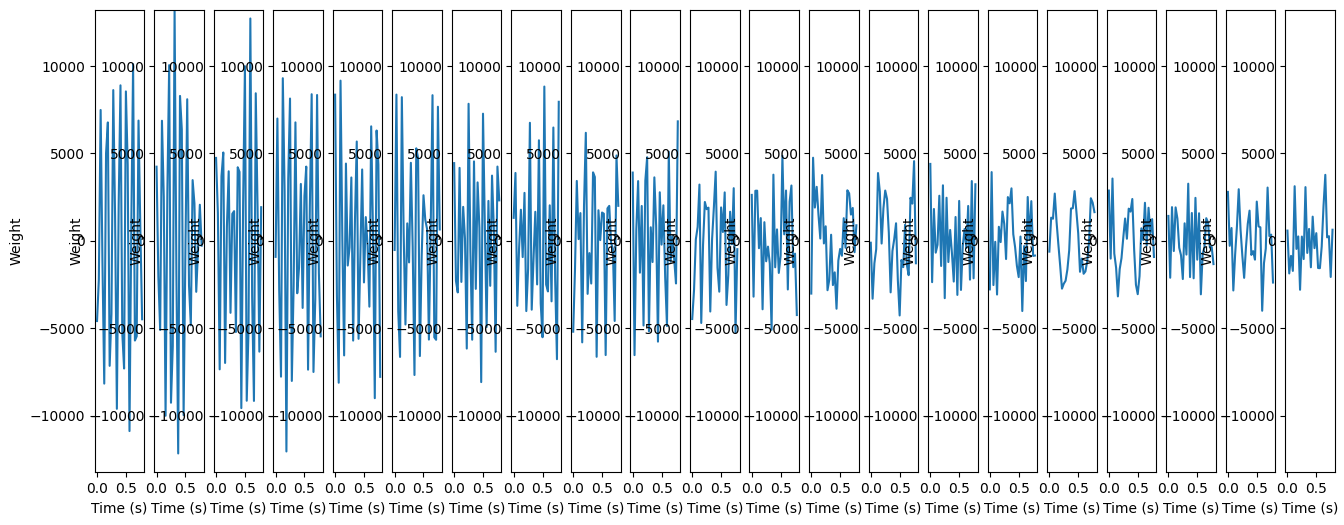

In [32]:
aps = [factors[k] @ hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]

fig, axs = plt.subplots(1,hoda.rank[0], figsize=(16,6))
for i in range(hoda.rank[0]):
    w = cupy.asnumpy(aps[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(aps[1]))
fig, axs = plt.subplots(1,hoda.rank[1], figsize=(16,6))
for i in range(hoda.rank[1]):
    w = cupy.asnumpy(aps[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])

In [33]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

#classifier = LogisticRegression(penalty='l1', solver='liblinear')
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)
classifier.fit(Xt_train,y_train)
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()

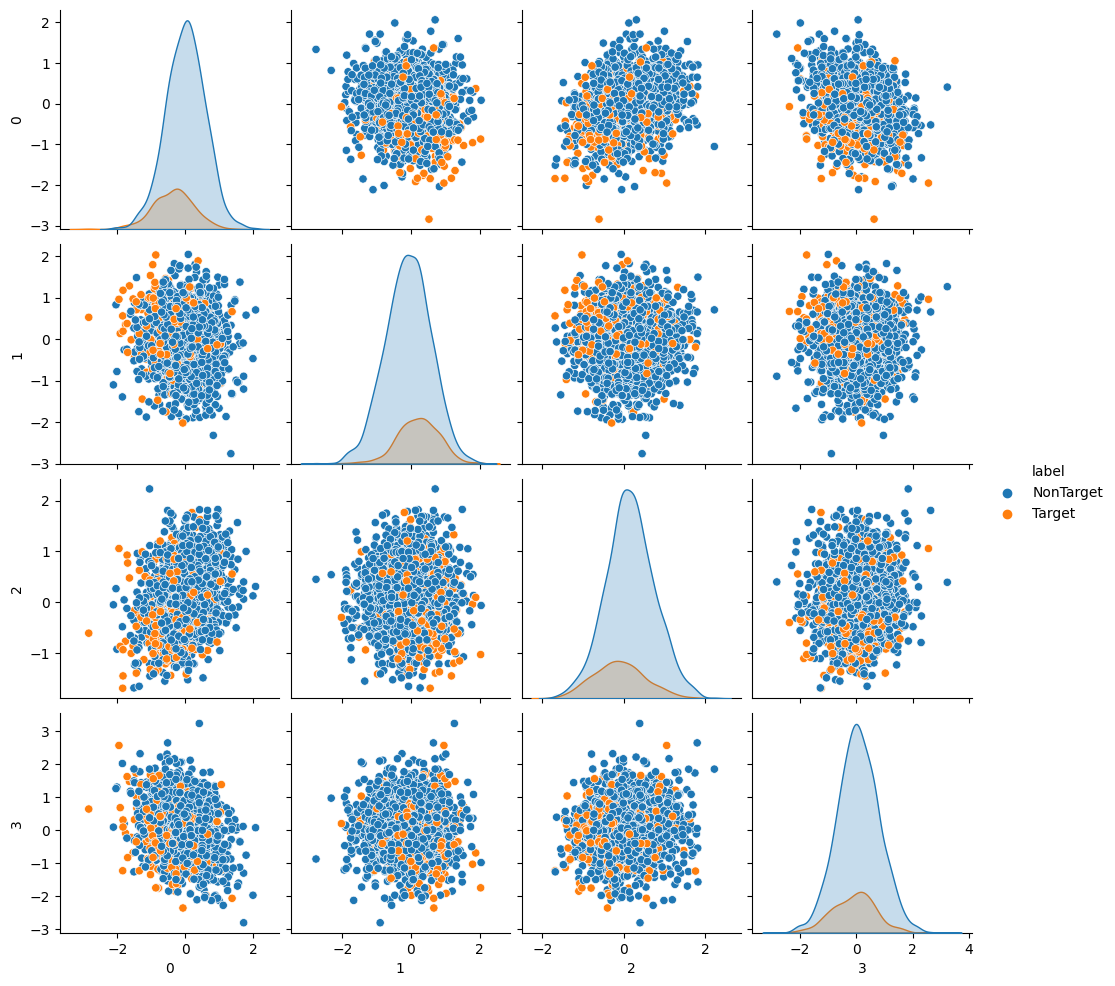

In [35]:
import seaborn as sns
import pandas as pd

n_features = Xt_train.shape[-1]
df_train = pd.DataFrame(Xt_train[:,feature_order[:4]])
df_train['label'] = y_train
g = sns.pairplot(df_train, hue='label')

In [36]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.7552163265306122

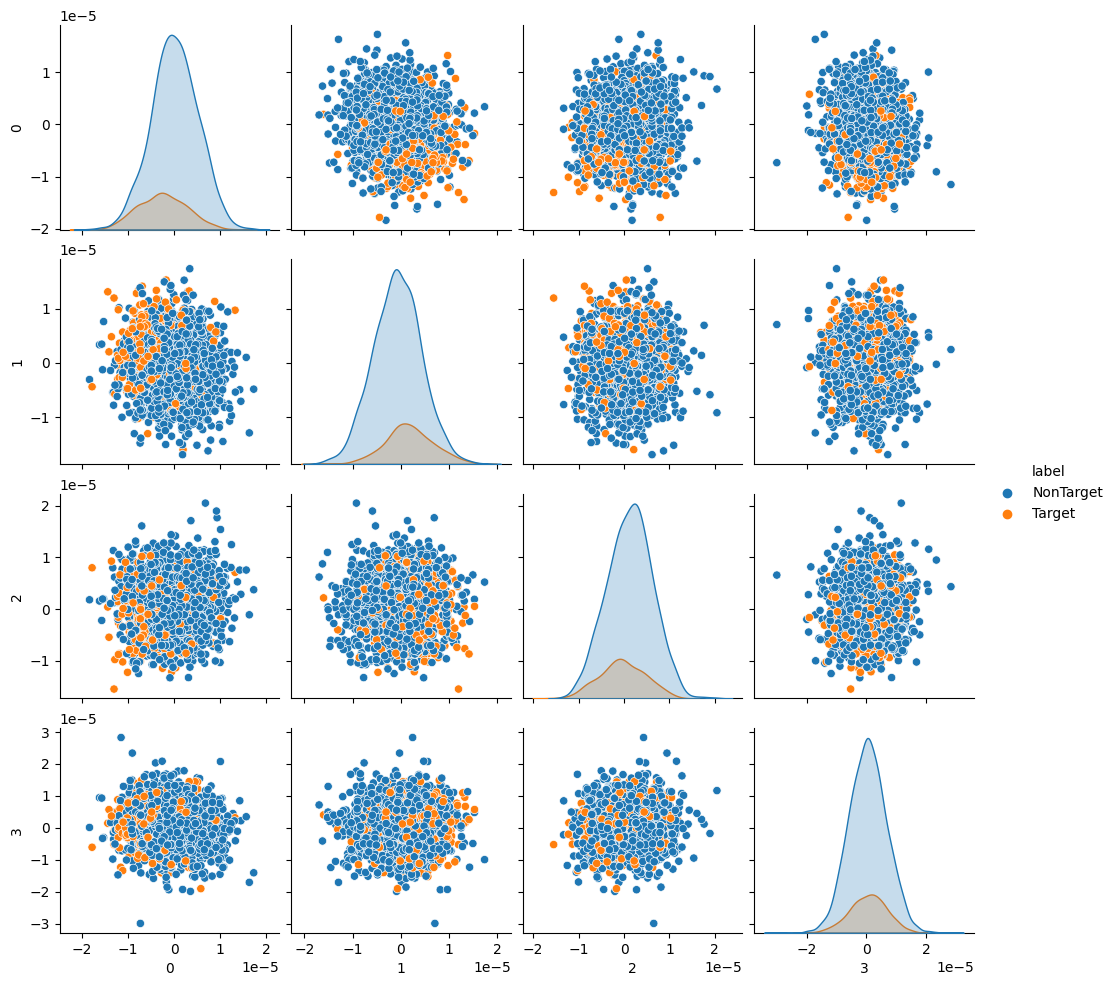

In [37]:
df_test = pd.DataFrame(Xt_test[:,feature_order[:4]])
df_test['label'] = y_test
g = sns.pairplot(df_test, hue='label')

In [38]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.70856